# Image Preprocessing & Augmentation Analysis

The goal is to study how preprocessing choices impact Re-ID performance.

In [1]:
import os
import sys
import yaml

import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms

In [2]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

In [3]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)["reid_project"]

In [4]:
from src.utils.preprocessing import convert_color_space, adjust_illumination, apply_image_filter, get_augmentation_pipeline
from src.utils.evaluator import evaluate
from src.dataloaders.market_dataset import MarketDataset
from src.models.resnet50 import ResNet50

In [5]:
dataset = MarketDataset(
    root_dir=config['market1501']['root_dir'], 
    subset='train', 
    transform=None
)

In [ ]:
raw_img = dataset.get_raw_image(0)

## 1. Color space analysis

Comparison between RGB, HSV, and LAB representations:

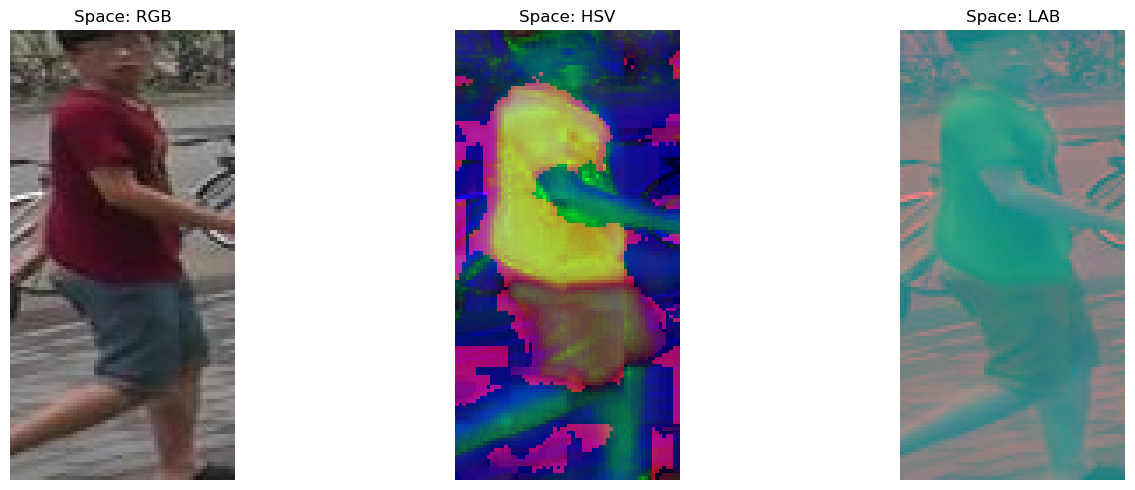

In [8]:
spaces = ['RGB', 'HSV', 'LAB']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, space in enumerate(spaces):
    img_conv = convert_color_space(raw_img, space=space)
    
    axes[i].imshow(img_conv)
    axes[i].set_title(f"Space: {space}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**RGB**: The original image shows a high correlation between the Red, Green, and Blue channels. This coupling makes the representation sensitive to lighting conditions: a shadow or a change in exposure affects all three channels simultaneously.

**HSV**: The transformation separates chromatic information (Hue/Saturation) from luminance (Value). This allows for easier isolation of the person's identity from the environmental lighting.

**LAB**: Designed to be perceptually uniform, it mimics how humans perceive color. The L channel captures lightness, while a and b encode color opponency (green-red and blue-yellow). It is highly effective for Re-ID as it standardizes color differences.

In [9]:
def plot_channel_decomposition(raw_img):
    """
    Visualizes individual channels for RGB, HSV, and LAB.
    """
    img_hsv = convert_color_space(raw_img, 'HSV')
    img_lab = convert_color_space(raw_img, 'LAB')
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    
    titles = [['R', 'G', 'B'], ['H', 'S', 'V'], ['L', 'a', 'b']]
    images = [raw_img, img_hsv, img_lab]
    
    for i in range(3):
        for j in range(3):
            channel_data = images[i][:, :, j]
            axes[i, j].imshow(channel_data, cmap='gray')
            axes[i, j].set_title(f"Channel {titles[i][j]}")
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

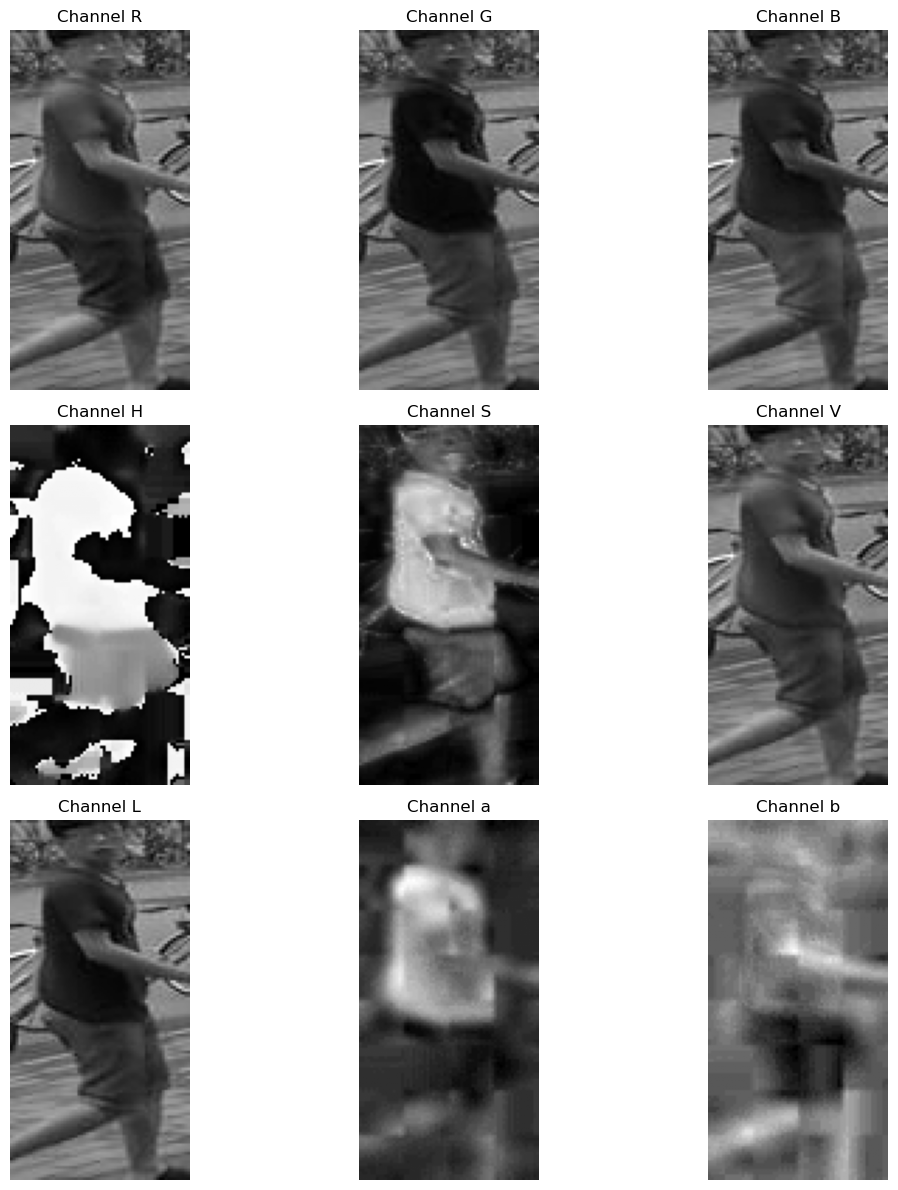

In [10]:
plot_channel_decomposition(raw_img)

Decomposing the image into nine distincts channels provides a more granular look at where the identity information is stored.

Channels V (HSV) and L (LAB) are grayscale versions of the image. They define the structure and edges of the pedestrian. 

Normalizing these specific channels could help the model ignore shadows while keeping the clothing patterns intact.

In the H channel, the pedetrian's red shirt appears as a distinct solid block. This channel is invariant to brightness changes and makes could be useful to identify the same person among different cameras.

In the a channel (green-red axis), the person's red shirt stands out from the background, could be a high signal for color detection.

Channels R, G, and B seem very similar to each other, highlighting their redundancy and why they are less robust to illumination variance when used individually without normalization.

In [11]:
def plot_distribution_analysis(raw_img):
    """
    Plots histograms for each channel in different spaces.
    """
    img_hsv = convert_color_space(raw_img, 'HSV')
    img_lab = convert_color_space(raw_img, 'LAB')
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['r', 'g', 'b']
    
    # RGB
    for i, color in enumerate(colors):
        hist = cv2.calcHist([raw_img], [i], None, [256], [0, 256])
        axes[0].plot(hist, color=color, label=f"Channel {color.upper()}")
    axes[0].set_title("RGB Distribution")
    axes[0].legend()

    # HSV
    h_hist = cv2.calcHist([img_hsv], [0], None, [180], [0, 180])
    axes[1].plot(h_hist, color='purple', label="Hue (H)")
    axes[1].set_title("Hue Distribution (HSV)")
    axes[1].legend()

    # LAB
    axes[2].plot(cv2.calcHist([img_lab], [1], None, [256], [0, 256]), color='orange', label="a (green-red)")
    axes[2].plot(cv2.calcHist([img_lab], [2], None, [256], [0, 256]), color='cyan', label="b (blue-yellow)")
    axes[2].set_title("Chromatic Distribution (LAB)")
    axes[2].legend()

    plt.show()

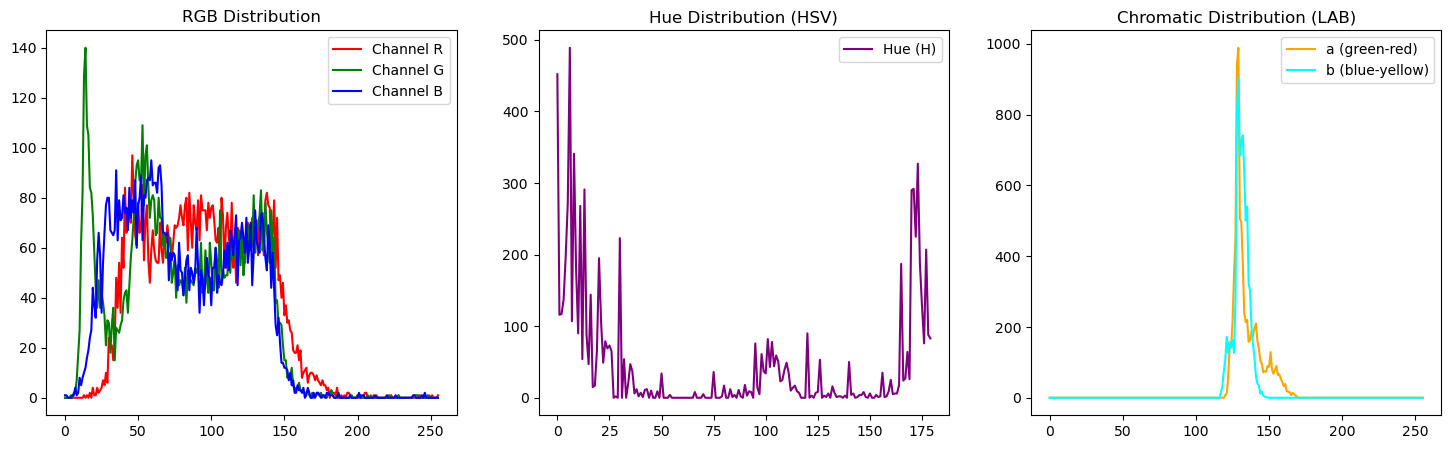

In [12]:
plot_distribution_analysis(raw_img)

The histograms quantify the characteristics of the person's appearance across different mathematical spaces.

The curves for R, G, and B are widely spread across the intensity range (50 to 150). The overlap between channels tells us that no single color channel in RGB can easily isolate the person's signature from the background noise.

In the Hue distribution however, we observe two sharp peaks at the extrem end of the spectrum (0-25 and 160-180). Because Hue is circular, these peaks correspond to the red/magenta spectrum of the person's shirt. This signature is much easier for a model to recognize than RGB.

Channels a and b are centered around 128 (neutral gray), this could be expected given the previous plots. However, we can see a small shilft to the right for the a channel which could confirm the presence of red tones. The narrowness of the peaks indicates a consistent color palette, which is essential for stable feature extraction.

## 2. Filtering Study

In [13]:
filters = ['gaussian', 'median', 'bilateral']
kernel_size = 5

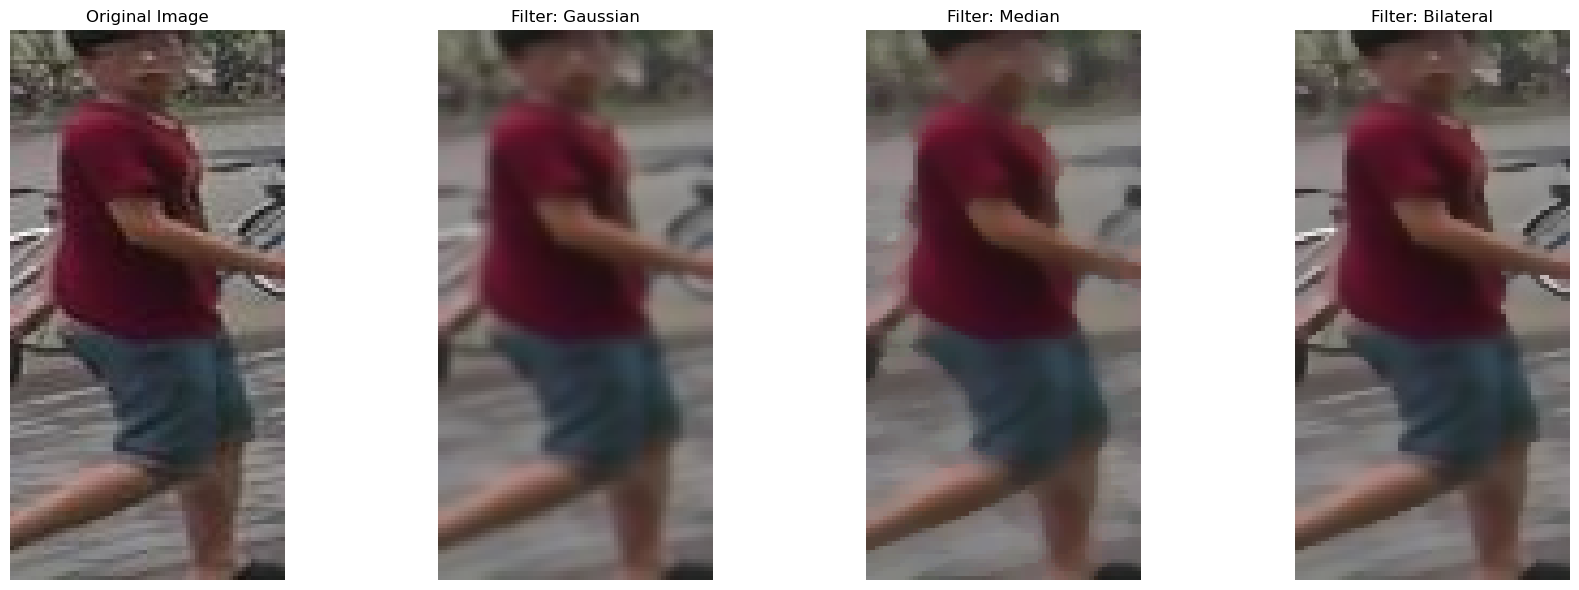

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(raw_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

for i, f_type in enumerate(filters):
    filtered_img = apply_image_filter(raw_img, filter_type=f_type, kernel_size=kernel_size)
    
    axes[i+1].imshow(filtered_img)
    axes[i+1].set_title(f"Filter: {f_type.capitalize()}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

This evaluates how the different spacial filters impacts the image in order for us to identify the best approach for noise reduction while maintaining feature integrity.

The baseline image contains standard sensor noise and sharp edges around the person's silhouette and clothing textures.

The Gaussian filter provides a smooth noise reduction by blurring the edges. However, for this project this this loss of high-frequency information, like the folds in the shirt or the boundary between the person and the background, can lead to degraded feature extraction by the CNN.

The Median filter removes impulse noise while keeping edges sharoer than the Gaussian one. However, it introduces a posterized/patchy effect on the person which could cause the texture to be misinterpreted.

The Bilateral filter, is non linear and achieves the best balance. It reduces noise in uniform areas while preserving the sharp edges of the person. It prevents bleeding of colors accross object boundaries, hence whiy it makes it better for this project.

## 3. Data Augmentation

In [15]:
aug_types = ['standard', 'color_jitter', 'random_erasing']

In [16]:
img_pil = Image.fromarray(raw_img)

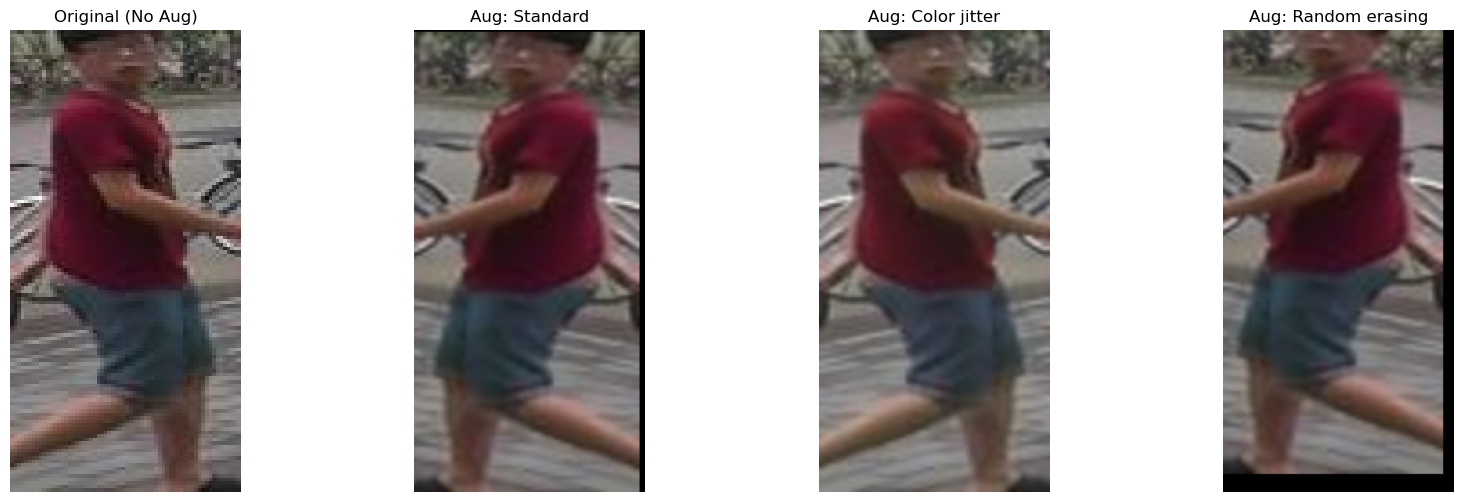

In [17]:
fig, axes = plt.subplots(1, len(aug_types) + 1, figsize=(20, 6))

axes[0].imshow(raw_img)
axes[0].set_title("Original (No Aug)")
axes[0].axis('off')

for i, aug in enumerate(aug_types):
    pipeline = get_augmentation_pipeline(aug)

    img_tensor = pipeline(img_pil)
    
    img_display = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = np.clip(std * img_display + mean, 0, 1)
    
    axes[i+1].imshow(img_display)
    axes[i+1].set_title(f"Aug: {aug.replace('_', ' ').capitalize()}")
    axes[i+1].axis('off')

The visual output demonstrates how various augmentation strategies modify the pedestrian's appearance to simulate real-world surveillance challenges.

In Standard, we observe a slight shift in the frame and a horizontal flip. This simulates varied person positioning within the bounding box and doubles the dataset diversity by mirroring identities.

In Color jitter, the image shows a noticeable shift in contrast and brightness. This is critical for Re-ID because a person's clothes can look different under different camera sensors or time-of-day lighting conditions. It prevents the model from relying on absolute pixel intensities.

In Random erasing, a rectangular patch of the image is replaced with random noise (visible in the tensor domain). This simulates occlusions.

## 4. Resolution Analysis

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50(
    num_classes=config['market1501']['num_classes'], 
    feature_dim=config["models"]["resnet50"]["feature_dim"],
    last_stride=config["models"]["resnet50"]["last_stride"]
)
model_path = "results/exp_resnet50_v1/resnet50_reid_epoch_1.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

ResNet50(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

In [ ]:
def get_features(model, loader):
    """Extracts features, PIDs, and CamIDs from a DataLoader."""
    features, pids, camids = [], [], []
    with torch.no_grad():
        for imgs, labels, cams in loader:
            imgs = imgs.to(device)
            feat = model(imgs) 
            features.append(feat.cpu())
            pids.extend(labels.numpy())
            camids.extend(cams.numpy())
    return torch.cat(features, 0), np.array(pids), np.array(camids)

In [ ]:
def run_resolution_benchmark(model, root_dir, resolutions):
    """
    Evaluates Re-ID performance across different input resolutions.
    """
    gallery_ds = MarketDataset(root_dir=root_dir, subset='test', transform=get_augmentation_pipeline('none'))
    gallery_loader = DataLoader(gallery_ds, batch_size=64, shuffle=False)

    print("Extracting high-resolution Gallery features...")
    g_feat, g_pids, g_camids = get_features(model, gallery_loader)
    
    results = {}

    for res in resolutions:
        print(f"\nEvaluating Resolution: {res[0]}x{res[1]}")
        degrade_transform = transforms.Compose([
            transforms.Resize(res, interpolation=Image.BILINEAR),
            transforms.Resize((256, 128), interpolation=Image.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        query_ds = MarketDataset(root_dir=root_dir, subset='query', transform=degrade_transform)
        query_loader = DataLoader(query_ds, batch_size=32, shuffle=False)

        q_feat, q_pids, q_camids = get_features(model, query_loader)
        
        rank1, mAP, _ = evaluate(q_feat, q_pids, g_feat, g_pids, q_camids, g_camids)
        
        results[res] = {'Rank-1': rank1, 'mAP': mAP}
        
        print(f"\nResolution {res} evaluated.")
        
    return results

In [24]:
resolutions = [(256, 128), (128, 64), (64, 32), (32, 16)]
benchmark_results = run_resolution_benchmark(model,
                                             config["market1501"]["root_dir"],
                                             resolutions)

Extracting high-resolution Gallery features...

Evaluating Resolution: 256x128
  Rank-1: 77.94% | Rank-5: 90.62% | Rank-10: 93.88% | mAP: 55.65%

Resolution (256, 128) evaluated.

Evaluating Resolution: 128x64
  Rank-1: 77.94% | Rank-5: 90.62% | Rank-10: 93.88% | mAP: 55.65%

Resolution (128, 64) evaluated.

Evaluating Resolution: 64x32
  Rank-1: 68.44% | Rank-5: 84.80% | Rank-10: 89.99% | mAP: 47.18%

Resolution (64, 32) evaluated.

Evaluating Resolution: 32x16
  Rank-1: 34.98% | Rank-5: 54.75% | Rank-10: 63.98% | mAP: 22.89%

Resolution (32, 16) evaluated.


The benchmark reveals a clear performance plateau followed by a critical collapse:

**256x128**: Baseline performance (1 epoch).\
**128x64**: Semantic preservation, negligible info loss.\
**64x32**: Significant decay, loss of structural edges.\
**32x16**: Performance collapse, reliance on color only.

The model exhibits high robustness down to 50% of its native resolution. 

However, a wall is hit at $64 \times 32$. For operational deployment, sensors must provide at least $2000$ pixels per person bounding box to maintain a Rank-1 above $60\%$. 

This highlights a trade-off between camera distance and identification reliability.

## Final Conclusion: Work Package 1 - Image Preprocessing & VR Analysis

**1. Feature-Rich Color Spaces:**

* We demonstrated that HSV and LAB spaces are superior for identity signature extraction compared to RGB.
* The Hue (H) and a (green-red) channels provide stable signatures that are partially invariant to illumination changes, which is critical for matching people across different camera views.


**2. Signal vs. Noise:**
* The Bilateral Filter was identified as the optimal preprocessing step. By smoothing uniform areas while preserving the edges of the person's silhouette, it maintains the information required for the CNN's deeper layers.

**3. Training Robustness (Augmentation):**
* Data augmentation acts as a regularizer. Specifically, Random Erasing forces the model to move from global recognition to part-based recognition, making the system robust to partial occlusions (such as backpacks, poles, or other people).

**4. Resolution analysis:**
* Our benchmark quantified the operational limit of the system. We identified a critical threshold at $64 \times 32$ pixels.
* Below this resolution, the Rank-1 accuracy drops by more than 50%, indicating that the model's structural feature extraction fails, and it reverts to a simple color-blob matching system.

**Transition to Work Package 2:** With the data pipeline validated and the model's limitations understood, we will now shift our focus to Model Architecture Analysis. We will use visualization tools like Grad-CAM to see if the model actually focuses on the same body parts as resolution decreases, and explore if architectural modifications (like attention mechanisms) can push the wall seen in the resolution analysis even further.